# Fine-tuning Classifier LLM


In [79]:
# setup - load packages
import pandas as pd
from datasets import Dataset
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns

seed = 13

In [93]:
# data in richtige Form
# read data
#data = pd.read_csv("/content/final_data.csv")
preprocessed_data = pd.read_csv("../data/final_data.csv")

# Selecting relevant df columns
preprocessed_data = preprocessed_data[['speech_text', 'party']]
# renaming label category
preprocessed_data = preprocessed_data.rename(columns={'party': 'label'})
# converting to huggingface dataset format
data = Dataset.from_pandas(preprocessed_data)


# splitting into train, test and validation sets
# party data
raw_dataset = data.shuffle(seed=seed)

# 70% train, 15% test, 15% validation data
split = raw_dataset.train_test_split(test_size=0.3, seed=seed)
train_data = split["train"]
text_and_val_data = split["test"]
split = text_and_val_data.train_test_split(test_size=0.5, seed=seed)
test_data = split["train"]
val_data = split["test"]

print(f"Training samples party: {len(train_data)}")
print(f"test samples party: {len(test_data)}")
print(f"Validation samples party: {len(val_data)}")



# data balancing??



Training samples party: 18662
test samples party: 3999
Validation samples party: 3999


In [ ]:
# second version - use stopwords on speech to only include meaningful parts of speeches
# preparing stopwords
# importing german stopword list from github
# link: https://github.com/solariz/german_stopwords
with open("german_stopwords_full.txt", "r", encoding="utf-8") as g:
    german_stopwords_full = [line.strip() for line in g if not line.lstrip().startswith(";")]
# list of words to add to stopwords:
more_stopwords = ["damen", "herren", "herr", "kollegen", "kolleginnen", "präsident", "präsidentin"]
# add list of additional words
german_stopwords_full.extend(more_stopwords)

# convert speeches to new coloumn, small letters and tokenized 
preprocessed_data["tokenized_speeches"] = preprocessed_data["speech_text"].str.lower().str.split()

# get rid of stopwords and special characters
preprocessed_data['tokenized_speeches'] = preprocessed_data['tokenized_speeches'].apply(lambda tokens: [word for word in tokens if word not in german_stopwords_full and word.isalpha()])

# re-join tokeized speeches to strings
preprocessed_data["speech_text"] = preprocessed_data["tokenized_speeches"].apply(lambda tokens: " ".join(tokens))

# drop helper column
preprocessed_data = preprocessed_data.drop(columns="tokenized_speeches", axis = 1)

# converting to huggingface dataset format
data = Dataset.from_pandas(preprocessed_data)


# splitting into train, test and validation sets
# party data
raw_dataset = data.shuffle(seed=seed)

# 70% train, 15% test, 15% validation data
split = raw_dataset.train_test_split(test_size=0.3, seed=seed)
v2_train_data = split["train"]
v2_text_and_val_data = split["test"]
split = v2_text_and_val_data.train_test_split(test_size=0.5, seed=seed)
v2_test_data = split["train"]
v2_val_data = split["test"]

print(f"Training samples party: {len(v2_train_data)}")
print(f"test samples party: {len(v2_test_data)}")
print(f"Validation samples party: {len(v2_val_data)}")

0        bankenunion stabilität stabilität erfahrungen ...
1        liebe liebe liebe gäste schön vorsitzenden fin...
2        liebe kollegin thema bankenunion verschlossene...
3        liebe kollege große fraktion geschämt dargebot...
4        liebe vorhin kollegin thema einlagensicherung ...
                               ...                        
26655    reise reise wolfratshausen stadt breiteren öff...
26656    demokratischen antrag union debattieren geschä...
26657    demokratischen unternehmen gekündigt wirtschaf...
26658    liebe frauen deutschland stehen jahr enormen s...
26659    liebe gesetzentwurf hinweisgeberschutz mitte f...
Name: speech_text, Length: 26660, dtype: object

In [94]:
# Load Model 
model_name = "bert-base-german-cased" 
num_labels = 6
max_length = 512
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels= num_labels) # classification head with one linear layer and num_label outputs is added on top of model here.

print(f"Model parameters: {model.num_parameters():,}")

# quantized?!

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-german-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model parameters: 109,085,958


In [103]:
# define prediction function
# Define possible label names
label_names = ['CDU/CSU', 'SPD', 'GRÜNE', 'FDP', 'AfD', 'LINKE']


def predicting_probs(model, speech, max_length=512):
    model.eval()

    # Tokenize full speech (no truncation)
    tokens = tokenizer(speech, return_tensors="pt", truncation=False)["input_ids"][0]

    # Split into chunks
    chunks = [tokens[i:i + max_length] for i in range(0, len(tokens), max_length)]

    # Pad chunks to max_length
    padded_chunks = []
    for chunk in chunks:
        if len(chunk) < max_length:
            # pad with pad_token_id
            padding = torch.full((max_length - len(chunk),), tokenizer.pad_token_id, dtype=torch.long)
            chunk = torch.cat([chunk, padding])
        padded_chunks.append(chunk)

    # Stack into batch tensor
    input_ids_batch = torch.stack(padded_chunks)
    attention_mask_batch = (input_ids_batch != tokenizer.pad_token_id).long()

    # Predict
    with torch.no_grad():
        outputs = model(input_ids=input_ids_batch, attention_mask=attention_mask_batch)
        logits = outputs.logits
        probabilities = torch.nn.functional.softmax(logits, dim=1)

    # Average over chunks
    avg_probs = torch.mean(probabilities, dim=0)

    return avg_probs



def predicting_probs_to_preds(model, speech):
    # get probabilites
    probabilities = predicting_probs(model, speech)
    # convert to predictions
    predictions_nr = torch.argmax(probabilities).item()
    predictions = label_names[predictions_nr]
    return predictions, probabilities



In [104]:
# collect evaluation data
def evaluate_model(model, data): 
    prediction_list = []
    probability_list = []
    true_label_list = []

    for i, row in enumerate(data):
        speech = row["speech_text"]
        pred, probs = predicting_probs_to_preds(model, speech)
        true_label = row["label"]
        prediction_list.append(pred)
        probability_list.append(probs)
        true_label_list.append(true_label)

        if (i+1) % 100 == 0:
            print(f"Processed samples {i+1} of {len(data)} samples.")

    return prediction_list, probability_list, true_label_list


# define function to display eval metrics
def get_metrics(true_labels, preds):
    metrics_summary = {}

    acc = accuracy_score(true_labels, preds)
    bal_acc = balanced_accuracy_score(true_labels, preds)

    precision = precision_score(true_labels, preds, average='macro', zero_division=0)
    recall = recall_score(true_labels, preds, average='macro', zero_division=0)
    f1 = f1_score(true_labels, preds, average='macro', zero_division=0)

    label_order = sorted(set(true_labels).union(set(preds)))
    report = classification_report(true_labels, preds, labels=label_order, zero_division=0)
    metrics_summary[model_name] = {
        'acc': acc,
        'bal_acc': bal_acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }
    # print metrics
    print(f"Model: {model_name}")
    print(f"  Accuracy: {acc}")
    print(f"  Balanced Accuracy: {bal_acc}")
    print(f"  Precision: {precision}")
    print(f"  Recall: {recall}")
    print(f"  F1-score: {f1}")
    print(f"  Classification Report:\n{report}")


    # Confusion Matrix
    label_order = sorted(set(true_labels).union(set(preds)))
    cm = confusion_matrix(true_labels, preds, labels=label_order)
    cm_df = pd.DataFrame(cm, index=label_order, columns=label_order)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()


    return metrics_summary



In [98]:
val_data = val_data.select(range(20))

[tensor([0.0795, 0.1360, 0.1214, 0.1719, 0.2809, 0.2103]), tensor([0.0745, 0.1569, 0.1290, 0.1394, 0.3119, 0.1883]), tensor([0.0675, 0.1780, 0.1243, 0.1490, 0.3004, 0.1808]), tensor([0.0594, 0.1651, 0.1273, 0.1692, 0.3015, 0.1775]), tensor([0.0620, 0.1703, 0.1354, 0.1722, 0.2716, 0.1884]), tensor([0.0805, 0.1653, 0.1205, 0.1637, 0.2720, 0.1980]), tensor([0.0736, 0.1412, 0.1082, 0.1823, 0.3037, 0.1910]), tensor([0.0642, 0.1743, 0.1415, 0.1428, 0.3075, 0.1697]), tensor([0.0603, 0.1642, 0.1608, 0.1511, 0.2848, 0.1788]), tensor([0.0811, 0.1554, 0.1315, 0.1474, 0.3117, 0.1729]), tensor([0.0652, 0.1698, 0.1307, 0.1546, 0.3067, 0.1730]), tensor([0.0719, 0.1515, 0.1332, 0.1596, 0.3096, 0.1742]), tensor([0.0661, 0.1680, 0.1434, 0.1527, 0.2761, 0.1937]), tensor([0.0647, 0.1514, 0.1282, 0.1715, 0.2722, 0.2119]), tensor([0.0664, 0.1707, 0.1271, 0.1583, 0.2765, 0.2010]), tensor([0.0665, 0.1487, 0.1350, 0.1664, 0.2800, 0.2034]), tensor([0.0650, 0.1365, 0.1580, 0.1678, 0.2810, 0.1918]), tensor([0.066

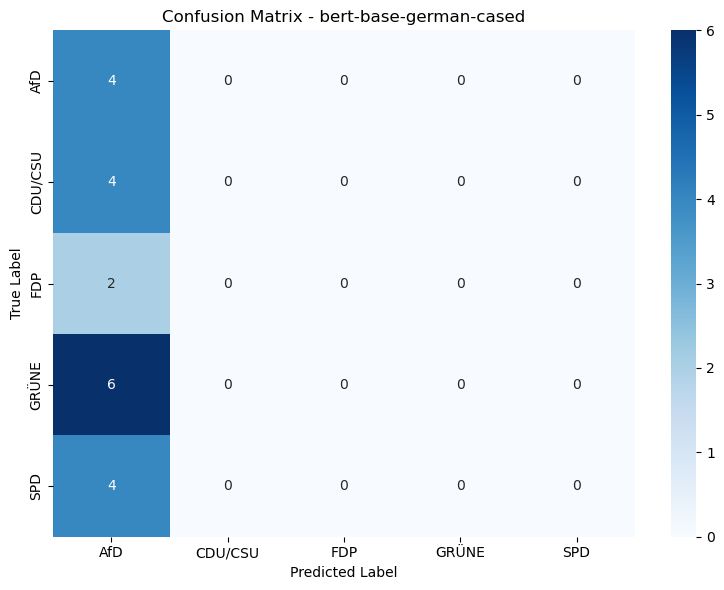

{'bert-base-german-cased': {'acc': 0.2,
  'bal_acc': 0.2,
  'precision': 0.04,
  'recall': 0.2,
  'f1': 0.06666666666666668}}

In [105]:
# Get zero-shot example performance 
prediction_list, probability_list, true_label_list = evaluate_model(model, val_data)
print(probability_list)
get_metrics(true_label_list, prediction_list)

In [ ]:
# fine-tunen



In [ ]:
# validaten



In [ ]:
# compare 2 versions (erinnern!)



In [ ]:
# outcomes test data conf matrix, accuracy



In [ ]:
# save model for futher tests on LLM generated speeches



__________________________________________________________________________________

Old to save
__________________________________________________________________________________

In [ ]:
# Load Model 
model_name = "bert-base-german-cased" 
num_labels = 6
max_length = 512
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels= num_labels) # classification head with one linear layer and num_label outputs is added on top of model here.

print(f"Model parameters: {model.num_parameters():,}")

# Put model in eval mode
model.eval()

# Define possible label names
label_names = ['CDU/CSU', 'SPD', 'GRÜNE', 'FDP', 'AfD', 'LINKE']

#  Tokenize input speeches
inputs = tokenizer(val_data_subset["speech_text"], return_tensors="pt", padding=True, truncation=False) # padding pads all speeches to the same length and truncation cuts all speeches to 512 tokens

# Run model to predict basline
with torch.no_grad(): # turns of gradient tracking, since we are not training
    outputs = model(**inputs) # passes tokenized inputs into model, returns output dict 
    logits = outputs.logits # output dict contains logits
    probabilities = F.softmax(logits, dim=1) # logits to probabilities
    predictions = torch.argmax(probabilities, dim=1) # probabilities to predictions (i.e. highest probability)

# 7. Print prediction examples
for i, pred in enumerate(predictions):
    print(f"Speech {i+1}: predicted party = {label_names[pred]}")
print(logits)

for i, probs in enumerate(probabilities):
    print(f"Speech {i+1} prediction:")
    for label, prob in zip(label_names, probs):
        print(f"  {label:7s}: {prob.item():.2%}")